In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# For running it locally
if os.getcwd().startswith("/home/lakrids"):
    path_prefix = "/home/lakrids/GenomeDK"
else:
    path_prefix = "/faststorage/project/"

In [15]:
# define species and username so that the files can be found
#species = "Naja_naja"
#species = "Rhinoceros_unicornis"
species = "Panthera_tigris"
#species = "Panthera_leo"
#species = "Panthera_pardus"
#species = "Panthera_uncia"
#species = "Boselaphus_tragocamelus"
#species = "Loxodonta_africana"
#species = "Loxodonta_cyclotis"
#species = "Diceros_bicornis"
#species = "Ceratotherium_simum"
#species = "Elephas_maximus"
# Loading in the dataset with sample ids, PCs, and geographic info
df = pd.read_csv(f"{path_prefix}/megaFauna/sa_megafauna/results/{species}/PCA/pca_dataset_{species}.txt", sep='\t')
# Loads the output of the allel.pca function. 
# This contains info about the variance explained by the different principal components as well.
with open(f"{path_prefix}/megaFauna/sa_megafauna/results/{species}/PCA/pca_model_{species}.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [12]:
# extract the variance
explained_var = loaded_model.explained_variance_ratio_  # if available
explained_var

array([0.06811332, 0.03835938, 0.03076105, 0.02956014, 0.02926858],
      dtype=float32)

In [13]:
# Load your PCA dataframe
# df = pd.read_csv("your_pca_file.csv")  # adapt as needed

# --- Remove outliers based on IQR of PC1 and PC2 ---
def remove_iqr_outliers(df, columns, multiplier=1.5):
    mask = pd.Series(True, index=df.index)
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        
        mask &= df[col].between(lower, upper)
        
        print(f"{col}: Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f} → keeping [{lower:.3f}, {upper:.3f}]")
    
    return df[mask]


df_clean = remove_iqr_outliers(df = df, columns=["PC1", "PC2"])

print(f"\nSamples before filtering: {len(df)}")
print(f"Samples removed:          {len(df) - len(df_clean)}")
print(f"Samples after filtering:  {len(df_clean)}")

PC1: Q1=-74.801, Q3=7.627, IQR=82.428 → keeping [-198.443, 131.268]
PC2: Q1=-98.238, Q3=51.195, IQR=149.433 → keeping [-322.387, 275.344]

Samples before filtering: 45
Samples removed:          6
Samples after filtering:  39


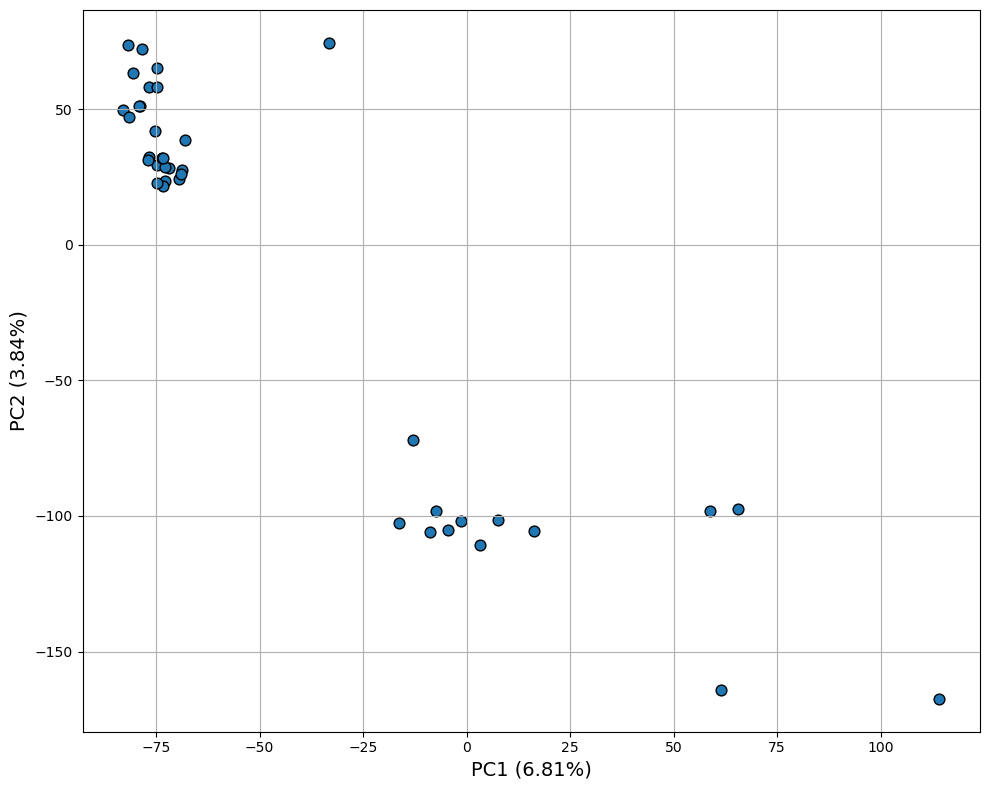

In [14]:
# 2. Create PCA scatter plot
df = df_clean
plt.figure(figsize=(10,8))
plt.scatter(df["PC1"], df["PC2"], edgecolor='black', s=60)
plt.xlabel(f"PC1 ({explained_var[0]*100:.2f}%)", fontsize=14)
plt.ylabel(f"PC2 ({explained_var[1]*100:.2f}%)", fontsize=14)
#plt.title(f'{"PC1"} vs {"PC2"} {species} colored by Geography')
plt.grid(True)
plt.tight_layout()

plt.savefig(f"{path_prefix}/megaFauna/sa_megafauna/results/{species}/PCA/PCA_{species}.png")
plt.show()

In [24]:
df[df["PC1"] >= 0][df["PC1"] <= 1000]
df[df["PC1"] >= 2000]
df.style

/tmp/ipykernel_10788/3633834276.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df["PC1"] >= 0][df["PC1"] <= 1000]


,IND_ID,PC1,PC2,PC3,PC4,PC5
0,SAMN02086964,-2501.028300,2121.002700,464.985400,921.080100,-202.109000
1,SAMN02086967,-1466.627900,-606.566900,357.621000,-1162.154800,-937.223400
2,SAMN03265429,-883.385130,77.489590,-178.078430,896.497200,-138.551480
3,SAMN09080448,540.039200,-457.138180,-1107.378300,470.922330,228.130660
4,SAMN09080449,528.666440,-463.249570,-1126.743900,475.641500,216.755400
5,SAMN09080471,174.614650,-304.229280,-701.625850,198.604340,-17.769590
6,SAMN09770316,-1997.605800,1429.632600,343.558960,116.077500,122.597750
7,SAMN09770317,-1879.182300,1561.590200,278.290220,793.811460,-50.799230
8,SAMN09770318,-2009.998300,1436.294400,347.526670,107.637660,120.260666
9,SAMN09770319,-1434.509000,706.552700,247.361570,171.972530,-160.476490


In [9]:
# 1. Assign colors based on geography from pca_df
geographies = pca_df['geography_simple'].fillna("Unknown")
unique_geos = geographies.unique()
palette = sns.color_palette("husl", len(unique_geos))
geo_color_map = dict(zip(unique_geos, palette))
colors = geographies.map(geo_color_map)

# 2. Create PCA scatter plot
plt.figure(figsize=(10,8))
plt.scatter(pca_df["PC1"], pca_df["PC2"], c=colors, edgecolor='black', s=60)
plt.xlabel(f"PC1 ({explained_var[0]*100:.2f}%)", fontsize=14)
plt.ylabel(f"PC2 ({explained_var[1]*100:.2f}%)", fontsize=14)
#plt.title(f'{"PC1"} vs {"PC2"} {species} colored by Geography')
plt.grid(True)
plt.tight_layout()

# 3. Add legend with sample counts
geo_counts = geographies.value_counts()
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               label=f"{geo} ({geo_counts[geo]})",
               markerfacecolor=geo_color_map[geo], markersize=8)
    for geo in unique_geos
]
plt.legend(handles=handles, title="Geography", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

KeyError: 'geography_simple'

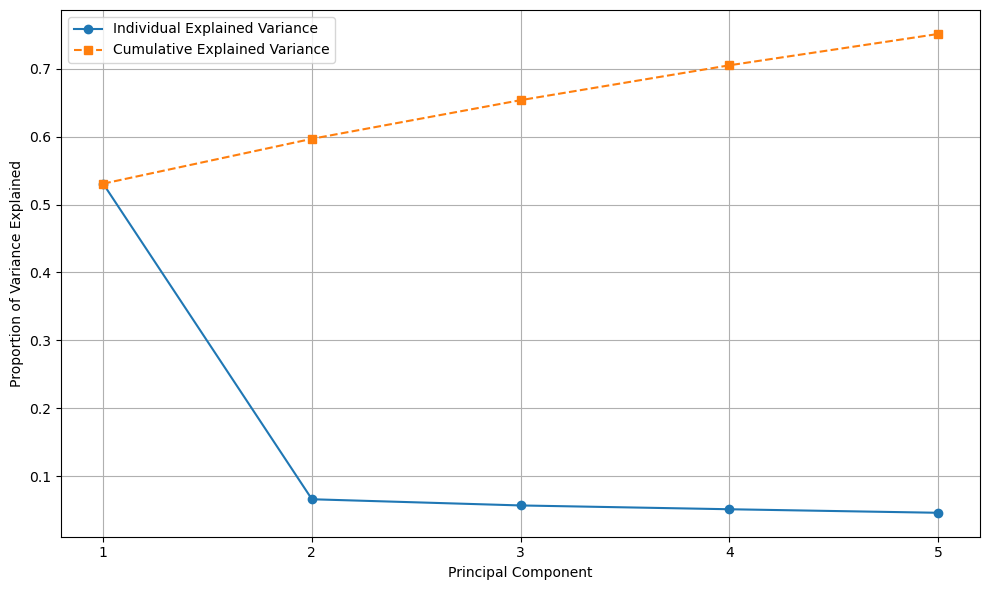

In [10]:
# Get explained variance from PCA model
explained_var = loaded_model.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 6))

# Plot individual variance
plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o', label='Individual Explained Variance')

# Plot cumulative variance
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='s', linestyle='--', label='Cumulative Explained Variance')

#plt.title(f'Scree Plot with Cumulative Variance for {species}')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(range(1, len(explained_var) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [22]:
population_name = "selected"
selected_ind = pca_df[(pca_df["PC2"] < 150) & (pca_df["PC2"] > 0)].IND_ID.tolist()
with open(f"{path_prefix}/megaFauna/sa_megafauna/results/{species}/PCA/population_{population_name}_{species}.txt", "w") as file:
    for ind in selected_ind:
        file.write(ind + "\n")